# Q2: Thực nghiệm Apriori vs FP-Growth - So sánh Độ Nhạy Tham Số

## Mục tiêu Thực Nghiệm

Notebook này thực hiện một thực nghiệm toàn diện để:

1. **Chạy Apriori và FP-Growth** trên cùng một `basket_bool` với các tham số khác nhau
2. **Quan sát và so sánh:**
   - Số lượng tập phổ biến (frequent itemsets)
   - Số lượng luật kết hợp sinh ra
   - Thời gian chạy khi `min_support` giảm dần
   - Độ dài trung bình của itemsets
   - Chất lượng luật (support, confidence, lift)
3. **Rút ra nhận xét** về độ nhạy tham số và giới hạn của từng thuật toán

## Tham số Thử Nghiệm

- **min_support**: Giảm từ 0.05 xuống 0.005 để quan sát sự thay đổi
- **min_confidence**: 0.1, 0.3, 0.5 để kiểm tra tác động
- **min_lift**: 1.0, 1.2 để so sánh chất lượng luật


## Setup và Chuẩn bị Dữ liệu

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Determine correct project root
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    project_root = os.path.abspath("..")
else:
    project_root = cwd

src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

from apriori_library import AssociationRulesMiner, FPGrowthMiner

# Thiết lập style cho biểu đồ
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

print("✓ Import libraries thành công")

✓ Import libraries thành công


In [2]:
# Tải basket_bool data
basket_bool_path = os.path.join(project_root, "notebooks/data/processed/basket_bool.parquet")

if not os.path.exists(basket_bool_path):
    # Thay vì từ parquet, tạo từ CSV đã làm sạch
    cleaned_data_path = os.path.join(project_root, "data/processed/cleaned_uk_data.csv")
    df_clean = pd.read_csv(cleaned_data_path, parse_dates=["InvoiceDate"])
    
    # Tạo basket dạng boolean
    basket_matrix = pd.crosstab(df_clean["InvoiceNo"], df_clean["Description"])
    basket_bool = (basket_matrix > 0).astype(int)
    
    # Lưu để tái sử dụng
    basket_bool.to_parquet(basket_bool_path)
    print(f"✓ Tạo basket_bool từ cleaned_uk_data.csv")
else:
    basket_bool = pd.read_parquet(basket_bool_path)
    print(f"✓ Tải basket_bool từ: {basket_bool_path}")

print(f"\n=== Thông tin Basket Data ===")
print(f"Số hoá đơn (rows): {basket_bool.shape[0]:,}")
print(f"Số sản phẩm (columns): {basket_bool.shape[1]:,}")
print(f"Tỷ lệ ô = 1 (sparsity): {basket_bool.values.mean():.4%}")
print(f"Kích thước dữ liệu: {basket_bool.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✓ Tải basket_bool từ: d:\KHMT_16-01\Data Mining\shopping_cart_advanced_analysis\notebooks/data/processed/basket_bool.parquet

=== Thông tin Basket Data ===
Số hoá đơn (rows): 18,021
Số sản phẩm (columns): 4,007
Tỷ lệ ô = 1 (sparsity): 0.6573%
Kích thước dữ liệu: 68.87 MB


## 1. Thử Nghiệm Độ Nhạy Min_Support

In [3]:
def test_parameter_sensitivity(basket_bool, min_supports, min_confidence=0.1, min_lift=1.0):
    """
    Chạy Apriori và FP-Growth với các giá trị min_support khác nhau.
    
    Args:
        basket_bool: DataFrame boolean-encoded basket
        min_supports: List các giá trị min_support cần test
        min_confidence: Minimum confidence cho rule generation
        min_lift: Minimum lift cho rule generation
    
    Returns:
        dict chứa kết quả so sánh
    """
    results = []
    
    for min_sup in min_supports:
        print(f"\n{'='*60}")
        print(f"Testing min_support = {min_sup}")
        print(f"{'='*60}")
        
        # ===== Apriori =====
        print("▶ Running Apriori...", end=" ")
        apriori_miner = AssociationRulesMiner(basket_bool=basket_bool)
        
        t_start = time.time()
        fi_ap = apriori_miner.mine_frequent_itemsets(
            min_support=min_sup,
            use_colnames=True,
            max_len=None
        )
        
        rules_ap = apriori_miner.generate_rules(
            metric="lift",
            min_threshold=min_lift
        )
        
        # Filter by min_confidence
        rules_ap_filtered = rules_ap[rules_ap['confidence'] >= min_confidence]
        t_apriori = time.time() - t_start
        
        avg_len_ap = fi_ap['itemsets'].apply(len).mean() if len(fi_ap) > 0 else 0
        print(f"✓ ({t_apriori:.4f}s)")
        
        # ===== FP-Growth =====
        print("▶ Running FP-Growth...", end=" ")
        fpg_miner = FPGrowthMiner(basket_bool=basket_bool)
        
        t_start = time.time()
        fi_fp = fpg_miner.mine_frequent_itemsets(
            min_support=min_sup,
            use_colnames=True,
            max_len=None
        )
        
        rules_fp = fpg_miner.generate_rules(
            metric="lift",
            min_threshold=min_lift
        )
        
        # Filter by min_confidence
        rules_fp_filtered = rules_fp[rules_fp['confidence'] >= min_confidence]
        t_fpgrowth = time.time() - t_start
        
        avg_len_fp = fi_fp['itemsets'].apply(len).mean() if len(fi_fp) > 0 else 0
        print(f"✓ ({t_fpgrowth:.4f}s)")
        
        # Collect statistics
        results.append({
            'min_support': min_sup,
            'min_confidence': min_confidence,
            'min_lift': min_lift,
            'apriori_time': t_apriori,
            'fpgrowth_time': t_fpgrowth,
            'apriori_itemsets': len(fi_ap),
            'fpgrowth_itemsets': len(fi_fp),
            'apriori_rules': len(rules_ap_filtered),
            'fpgrowth_rules': len(rules_fp_filtered),
            'apriori_avg_itemset_len': avg_len_ap,
            'fpgrowth_avg_itemset_len': avg_len_fp,
            'apriori_rules_obj': rules_ap_filtered,
            'fpgrowth_rules_obj': rules_fp_filtered,
        })
    
    return pd.DataFrame(results)

# Định nghĩa các tham số min_support cần test (từ 0.05 xuống 0.02)
min_support_values = [0.05, 0.04, 0.03, 0.02]

print("Bắt đầu thử nghiệm với min_confidence = 0.1, min_lift = 1.0")
results_df = test_parameter_sensitivity(
    basket_bool=basket_bool,
    min_supports=min_support_values,
    min_confidence=0.1,
    min_lift=1.0
)

print("\n" + "="*60)
print("✓ Hoàn thành thử nghiệm")
print("="*60)

Bắt đầu thử nghiệm với min_confidence = 0.1, min_lift = 1.0

Testing min_support = 0.05
▶ Running Apriori... ✓ (0.0892s)
▶ Running FP-Growth... ✓ (2.6227s)

Testing min_support = 0.04
▶ Running Apriori... ✓ (0.1558s)
▶ Running FP-Growth... ✓ (2.8264s)

Testing min_support = 0.03
▶ Running Apriori... ✓ (0.3828s)
▶ Running FP-Growth... ✓ (3.3622s)

Testing min_support = 0.02
▶ Running Apriori... ✓ (1.7639s)
▶ Running FP-Growth... ✓ (7.4305s)

✓ Hoàn thành thử nghiệm


In [4]:
# Hiển thị bảng kết quả chi tiết
display_df = results_df.copy()
display_df = display_df[[
    'min_support',
    'apriori_time', 'fpgrowth_time',
    'apriori_itemsets', 'fpgrowth_itemsets',
    'apriori_rules', 'fpgrowth_rules',
    'apriori_avg_itemset_len', 'fpgrowth_avg_itemset_len'
]].round(4)

print("\n=== KẾT QUẢ CHI TIẾT ===\n")
display(display_df)


=== KẾT QUẢ CHI TIẾT ===



,min_support,apriori_time,fpgrowth_time,apriori_itemsets,fpgrowth_itemsets,apriori_rules,fpgrowth_rules,apriori_avg_itemset_len,fpgrowth_avg_itemset_len
0,0.05,0.0892,2.6227,34,34,0,0,1.0000,1.0000
1,0.04,0.1558,2.8264,66,66,2,2,1.0152,1.0152
2,0.03,0.3828,3.3622,145,145,22,22,1.0759,1.0759
3,0.02,1.7639,7.4305,400,400,218,218,1.2625,1.2625


## 2. So Sánh Số Lượng Frequent Itemsets

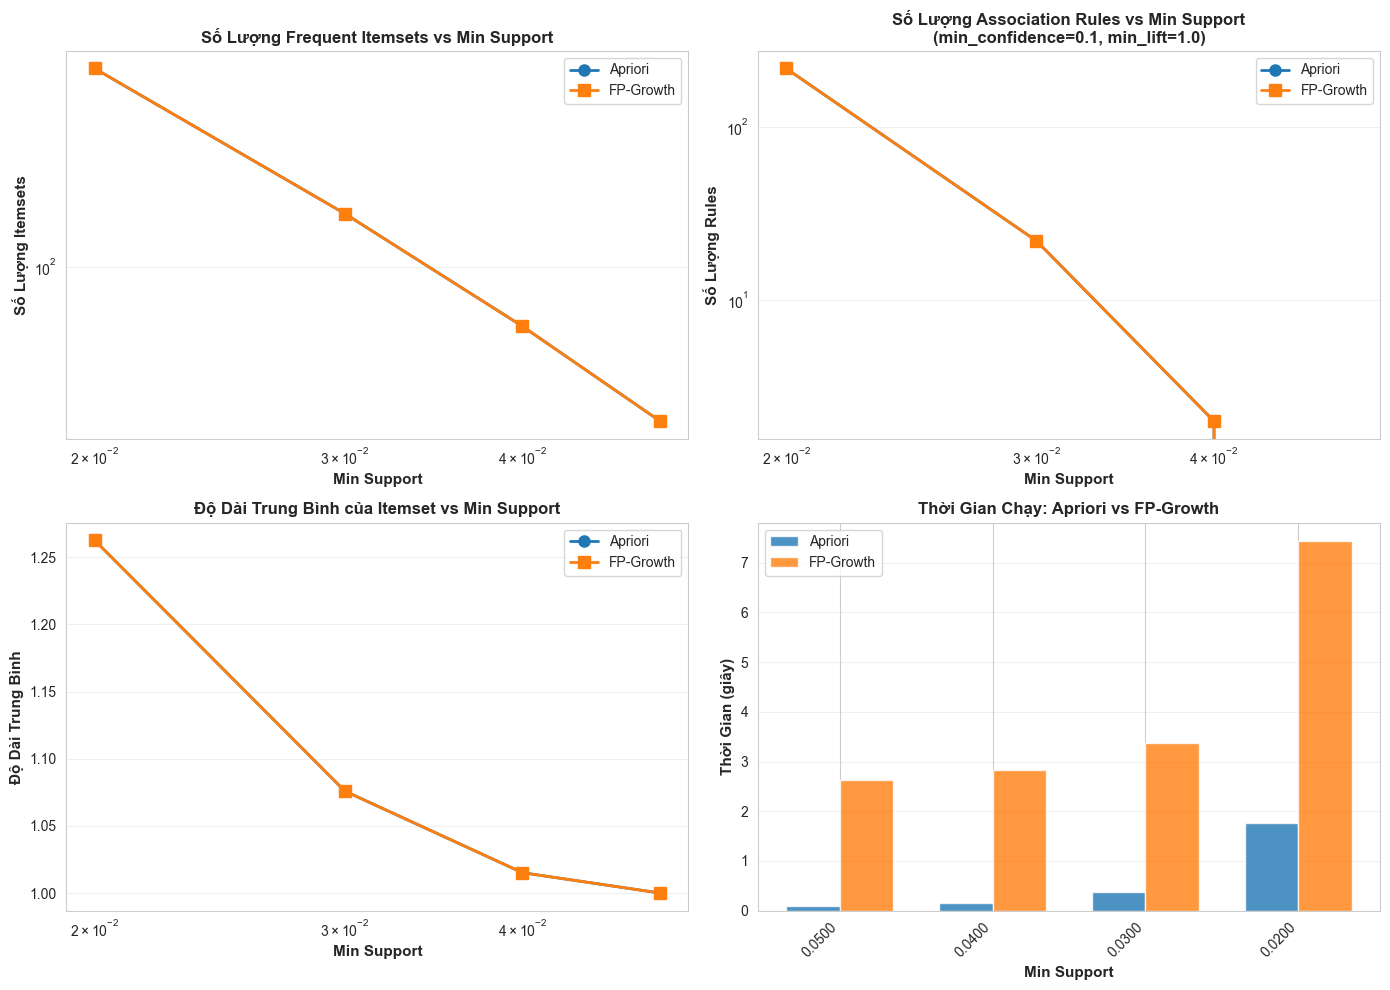


✓ Biểu đồ so sánh tham số min_support


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Số lượng Frequent Itemsets
ax = axes[0, 0]
ax.plot(results_df['min_support'], results_df['apriori_itemsets'], 
        marker='o', label='Apriori', linewidth=2, markersize=8)
ax.plot(results_df['min_support'], results_df['fpgrowth_itemsets'], 
        marker='s', label='FP-Growth', linewidth=2, markersize=8)
ax.set_xlabel('Min Support', fontsize=11, fontweight='bold')
ax.set_ylabel('Số Lượng Itemsets', fontsize=11, fontweight='bold')
ax.set_title('Số Lượng Frequent Itemsets vs Min Support', fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Số lượng Rules
ax = axes[0, 1]
ax.plot(results_df['min_support'], results_df['apriori_rules'], 
        marker='o', label='Apriori', linewidth=2, markersize=8)
ax.plot(results_df['min_support'], results_df['fpgrowth_rules'], 
        marker='s', label='FP-Growth', linewidth=2, markersize=8)
ax.set_xlabel('Min Support', fontsize=11, fontweight='bold')
ax.set_ylabel('Số Lượng Rules', fontsize=11, fontweight='bold')
ax.set_title('Số Lượng Association Rules vs Min Support\n(min_confidence=0.1, min_lift=1.0)', 
             fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Độ dài trung bình itemset
ax = axes[1, 0]
ax.plot(results_df['min_support'], results_df['apriori_avg_itemset_len'], 
        marker='o', label='Apriori', linewidth=2, markersize=8)
ax.plot(results_df['min_support'], results_df['fpgrowth_avg_itemset_len'], 
        marker='s', label='FP-Growth', linewidth=2, markersize=8)
ax.set_xlabel('Min Support', fontsize=11, fontweight='bold')
ax.set_ylabel('Độ Dài Trung Bình', fontsize=11, fontweight='bold')
ax.set_title('Độ Dài Trung Bình của Itemset vs Min Support', fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Hiệu suất
ax = axes[1, 1]
x_pos = np.arange(len(results_df))
width = 0.35
ax.bar(x_pos - width/2, results_df['apriori_time'], width, label='Apriori', alpha=0.8)
ax.bar(x_pos + width/2, results_df['fpgrowth_time'], width, label='FP-Growth', alpha=0.8)
ax.set_xlabel('Min Support', fontsize=11, fontweight='bold')
ax.set_ylabel('Thời Gian (giây)', fontsize=11, fontweight='bold')
ax.set_title('Thời Gian Chạy: Apriori vs FP-Growth', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{x:.4f}' for x in results_df['min_support']], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Biểu đồ so sánh tham số min_support")


## 3. Phân Tích Chi Tiết Thời Gian Chạy

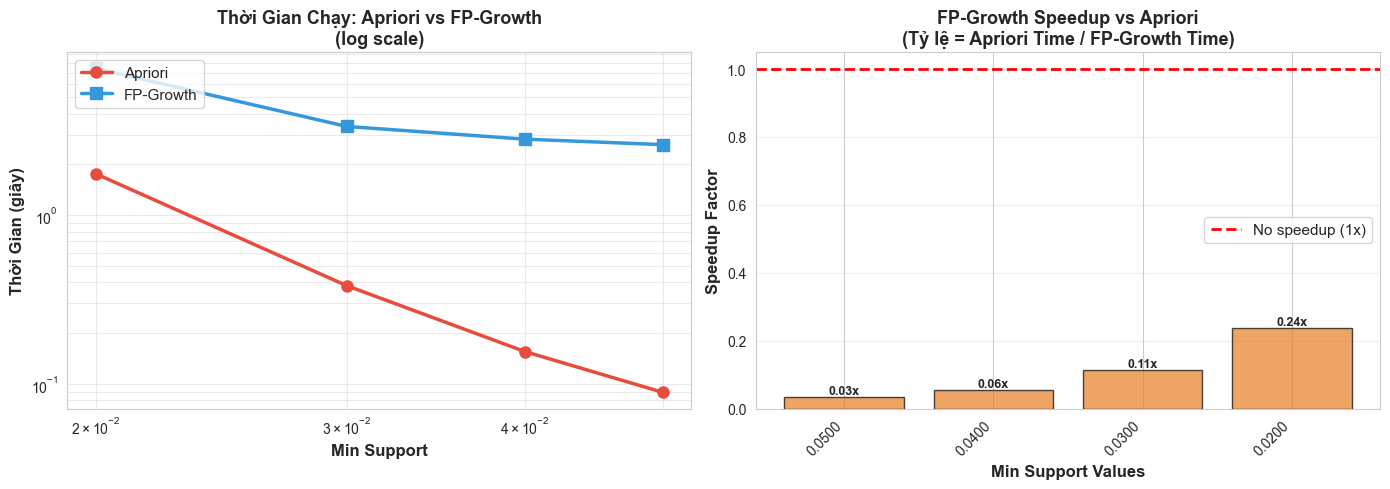


=== SO SÁNH THỜI GIAN CHẠY ===



,Min Support,Apriori (s),FP-Growth (s),Speedup (x)
0,0.05,0.0892,2.6227,0.0340
1,0.04,0.1558,2.8264,0.0551
2,0.03,0.3828,3.3622,0.1139
3,0.02,1.7639,7.4305,0.2374



📊 Thống kê Speedup:
   - Speedup trung bình: 0.11x
   - Speedup tối đa: 0.24x
   - Speedup tối thiểu: 0.03x


In [6]:
# Tính toán speedup của FP-Growth so với Apriori
results_df['speedup_factor'] = results_df['apriori_time'] / results_df['fpgrowth_time']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Thời gian chạy (log scale)
ax = axes[0]
ax.plot(results_df['min_support'], results_df['apriori_time'], 
        marker='o', label='Apriori', linewidth=2.5, markersize=8, color='#e74c3c')
ax.plot(results_df['min_support'], results_df['fpgrowth_time'], 
        marker='s', label='FP-Growth', linewidth=2.5, markersize=8, color='#3498db')
ax.set_xlabel('Min Support', fontsize=12, fontweight='bold')
ax.set_ylabel('Thời Gian (giây)', fontsize=12, fontweight='bold')
ax.set_title('Thời Gian Chạy: Apriori vs FP-Growth\n(log scale)', 
             fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.4, which='both')

# Plot 2: Speedup factor
ax = axes[1]
colors = ['#2ecc71' if x > 1 else '#e67e22' for x in results_df['speedup_factor']]
bars = ax.bar(range(len(results_df)), results_df['speedup_factor'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=1, color='red', linestyle='--', linewidth=2, label='No speedup (1x)')
ax.set_xlabel('Min Support Values', fontsize=12, fontweight='bold')
ax.set_ylabel('Speedup Factor', fontsize=12, fontweight='bold')
ax.set_title('FP-Growth Speedup vs Apriori\n(Tỷ lệ = Apriori Time / FP-Growth Time)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels([f'{x:.4f}' for x in results_df['min_support']], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Thêm nhãn giá trị trên cột
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}x',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# In bảng so sánh thời gian
print("\n=== SO SÁNH THỜI GIAN CHẠY ===\n")
time_comparison = results_df[['min_support', 'apriori_time', 'fpgrowth_time', 'speedup_factor']].copy()
time_comparison.columns = ['Min Support', 'Apriori (s)', 'FP-Growth (s)', 'Speedup (x)']
time_comparison = time_comparison.round(4)
display(time_comparison)

print(f"\n📊 Thống kê Speedup:")
print(f"   - Speedup trung bình: {results_df['speedup_factor'].mean():.2f}x")
print(f"   - Speedup tối đa: {results_df['speedup_factor'].max():.2f}x")
print(f"   - Speedup tối thiểu: {results_df['speedup_factor'].min():.2f}x")

## 4. Thử Nghiệm Độ Nhạy Min_Confidence

Thử nghiệm độ nhạy min_confidence...

Testing min_confidence = 0.1

Testing min_confidence = 0.3

Testing min_confidence = 0.5

Testing min_confidence = 0.7

Testing min_confidence = 0.9


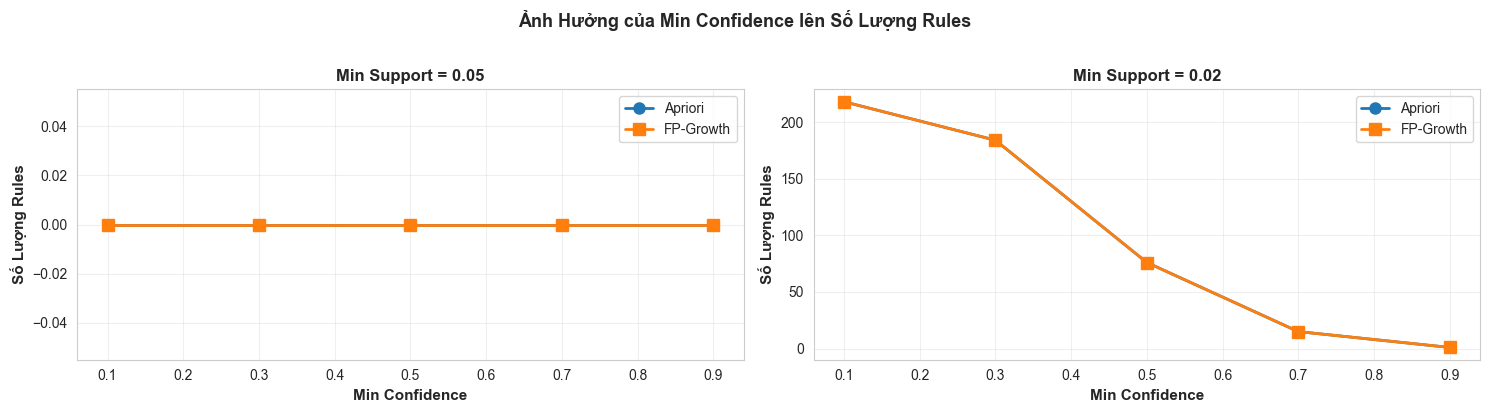


✓ Biểu đồ độ nhạy min_confidence


In [7]:
def test_confidence_sensitivity(basket_bool, min_supports_test, min_confidences, min_lift=1.0):
    """
    Chạy với các giá trị min_confidence khác nhau
    """
    results_conf = []
    
    for min_conf in min_confidences:
        print(f"\nTesting min_confidence = {min_conf}")
        
        # Chọn một vài min_support tiêu biểu
        for min_sup in min_supports_test:
            # Apriori
            apriori_miner = AssociationRulesMiner(basket_bool=basket_bool)
            apriori_miner.mine_frequent_itemsets(min_support=min_sup, use_colnames=True)
            rules_ap = apriori_miner.generate_rules(metric="lift", min_threshold=min_lift)
            rules_ap_filt = rules_ap[rules_ap['confidence'] >= min_conf]
            
            # FP-Growth
            fpg_miner = FPGrowthMiner(basket_bool=basket_bool)
            fpg_miner.mine_frequent_itemsets(min_support=min_sup, use_colnames=True)
            rules_fp = fpg_miner.generate_rules(metric="lift", min_threshold=min_lift)
            rules_fp_filt = rules_fp[rules_fp['confidence'] >= min_conf]
            
            results_conf.append({
                'min_support': min_sup,
                'min_confidence': min_conf,
                'apriori_rules': len(rules_ap_filt),
                'fpgrowth_rules': len(rules_fp_filt)
            })
    
    return pd.DataFrame(results_conf)

# Test với một số min_support tiêu biểu
test_supports = [0.05, 0.02]
test_confidences = [0.1, 0.3, 0.5, 0.7, 0.9]

print("Thử nghiệm độ nhạy min_confidence...")
conf_sensitivity = test_confidence_sensitivity(
    basket_bool=basket_bool,
    min_supports_test=test_supports,
    min_confidences=test_confidences,
    min_lift=1.0
)

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for idx, min_sup in enumerate(test_supports):
    ax = axes[idx]
    subset = conf_sensitivity[conf_sensitivity['min_support'] == min_sup]
    
    ax.plot(subset['min_confidence'], subset['apriori_rules'], 
            marker='o', label='Apriori', linewidth=2, markersize=8)
    ax.plot(subset['min_confidence'], subset['fpgrowth_rules'], 
            marker='s', label='FP-Growth', linewidth=2, markersize=8)
    
    ax.set_xlabel('Min Confidence', fontsize=11, fontweight='bold')
    ax.set_ylabel('Số Lượng Rules', fontsize=11, fontweight='bold')
    ax.set_title(f'Min Support = {min_sup}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Ảnh Hưởng của Min Confidence lên Số Lượng Rules', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Biểu đồ độ nhạy min_confidence")

## 5. Phân Tích Chất Lượng Luật (Support, Confidence, Lift)

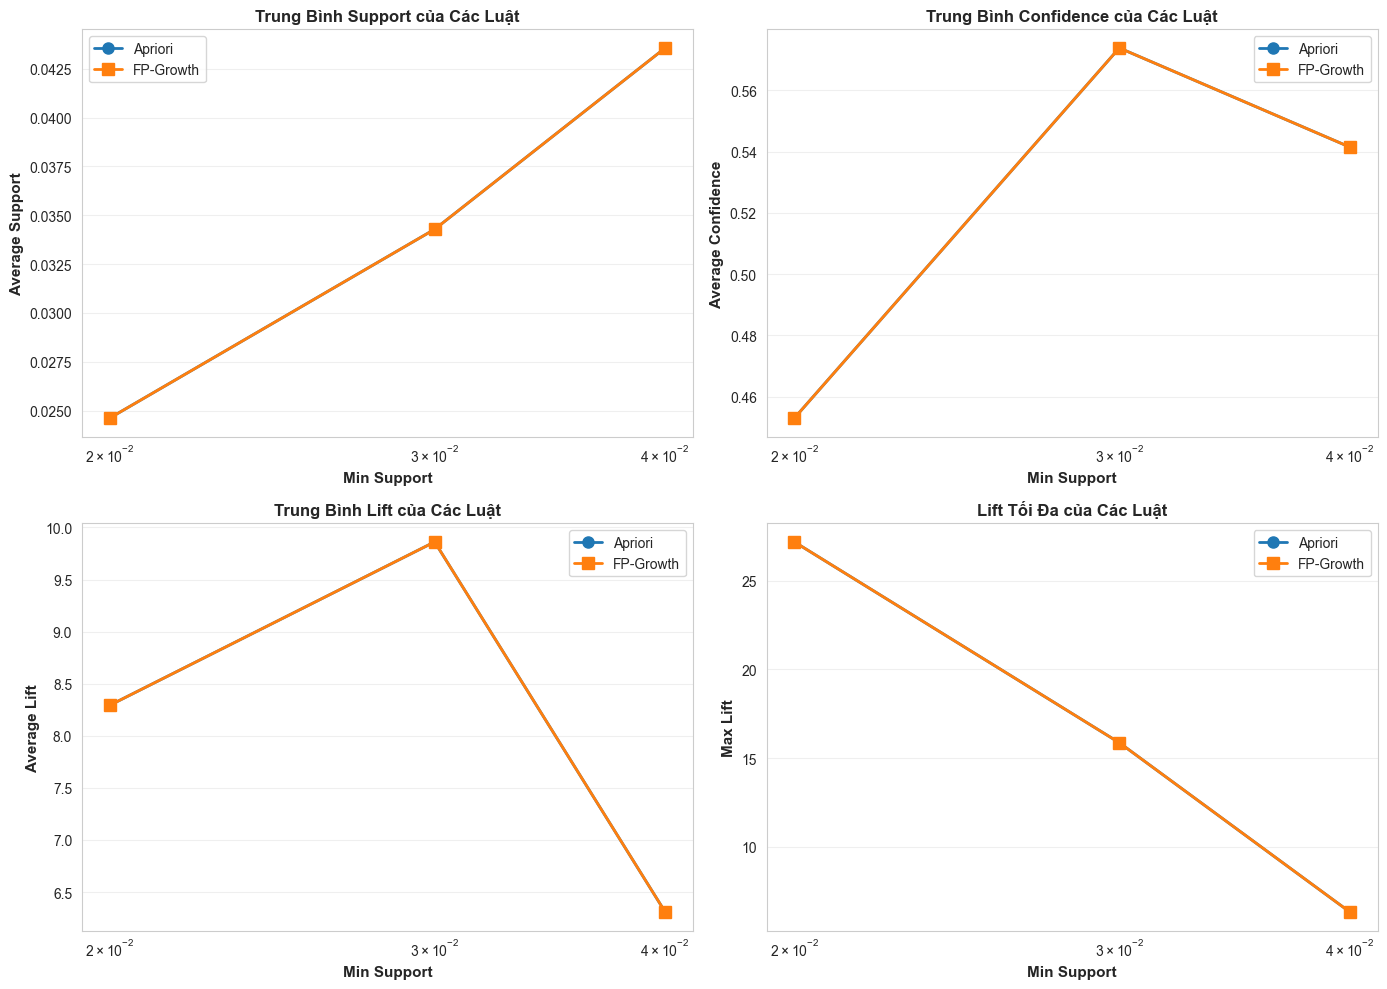


✓ Biểu đồ chất lượng luật


In [8]:
# Lấy các luật từ một số điểm tiêu biểu để phân tích chất lượng
quality_metrics = []

for idx, row in results_df.iterrows():
    min_sup = row['min_support']
    rules_ap = row['apriori_rules_obj']
    rules_fp = row['fpgrowth_rules_obj']
    
    if len(rules_ap) > 0:
        quality_metrics.append({
            'min_support': min_sup,
            'algorithm': 'Apriori',
            'avg_support': rules_ap['support'].mean(),
            'avg_confidence': rules_ap['confidence'].mean(),
            'avg_lift': rules_ap['lift'].mean(),
            'max_lift': rules_ap['lift'].max(),
            'num_rules': len(rules_ap)
        })
    
    if len(rules_fp) > 0:
        quality_metrics.append({
            'min_support': min_sup,
            'algorithm': 'FP-Growth',
            'avg_support': rules_fp['support'].mean(),
            'avg_confidence': rules_fp['confidence'].mean(),
            'avg_lift': rules_fp['lift'].mean(),
            'max_lift': rules_fp['lift'].max(),
            'num_rules': len(rules_fp)
        })

quality_df = pd.DataFrame(quality_metrics)

# Vẽ biểu đồ chất lượng luật
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Average Support
ax = axes[0, 0]
for alg in ['Apriori', 'FP-Growth']:
    subset = quality_df[quality_df['algorithm'] == alg]
    marker = 'o' if alg == 'Apriori' else 's'
    ax.plot(subset['min_support'], subset['avg_support'], 
            marker=marker, label=alg, linewidth=2, markersize=8)
ax.set_xlabel('Min Support', fontsize=11, fontweight='bold')
ax.set_ylabel('Average Support', fontsize=11, fontweight='bold')
ax.set_title('Trung Bình Support của Các Luật', fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Average Confidence
ax = axes[0, 1]
for alg in ['Apriori', 'FP-Growth']:
    subset = quality_df[quality_df['algorithm'] == alg]
    marker = 'o' if alg == 'Apriori' else 's'
    ax.plot(subset['min_support'], subset['avg_confidence'], 
            marker=marker, label=alg, linewidth=2, markersize=8)
ax.set_xlabel('Min Support', fontsize=11, fontweight='bold')
ax.set_ylabel('Average Confidence', fontsize=11, fontweight='bold')
ax.set_title('Trung Bình Confidence của Các Luật', fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Average Lift
ax = axes[1, 0]
for alg in ['Apriori', 'FP-Growth']:
    subset = quality_df[quality_df['algorithm'] == alg]
    marker = 'o' if alg == 'Apriori' else 's'
    ax.plot(subset['min_support'], subset['avg_lift'], 
            marker=marker, label=alg, linewidth=2, markersize=8)
ax.set_xlabel('Min Support', fontsize=11, fontweight='bold')
ax.set_ylabel('Average Lift', fontsize=11, fontweight='bold')
ax.set_title('Trung Bình Lift của Các Luật', fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Max Lift
ax = axes[1, 1]
for alg in ['Apriori', 'FP-Growth']:
    subset = quality_df[quality_df['algorithm'] == alg]
    marker = 'o' if alg == 'Apriori' else 's'
    ax.plot(subset['min_support'], subset['max_lift'], 
            marker=marker, label=alg, linewidth=2, markersize=8)
ax.set_xlabel('Min Support', fontsize=11, fontweight='bold')
ax.set_ylabel('Max Lift', fontsize=11, fontweight='bold')
ax.set_title('Lift Tối Đa của Các Luật', fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Biểu đồ chất lượng luật")

In [9]:
# Bảng tóm tắt chất lượng luật
print("\n=== SO SÁNH CHẤT LƯỢNG LUẬT ===\n")
quality_summary = quality_df.pivot_table(
    index='min_support',
    columns='algorithm',
    values=['avg_support', 'avg_confidence', 'avg_lift', 'max_lift'],
    aggfunc='first'
)

display(quality_summary.round(4))


=== SO SÁNH CHẤT LƯỢNG LUẬT ===



avg_confidence           avg_lift           avg_support            \
algorithm          Apriori FP-Growth  Apriori FP-Growth     Apriori FP-Growth   
min_support                                                                     
0.02                0.4529    0.4529   8.2923    8.2923      0.0246    0.0246   
0.03                0.5739    0.5739   9.8613    9.8613      0.0343    0.0343   
0.04                0.5415    0.5415   6.3079    6.3079      0.0436    0.0436   

            max_lift            
algorithm    Apriori FP-Growth  
min_support                     
0.02         27.2003   27.2003  
0.03         15.8653   15.8653  
0.04          6.3079    6.3079

## 6. Phân Tích Phân Phối Support, Confidence, Lift

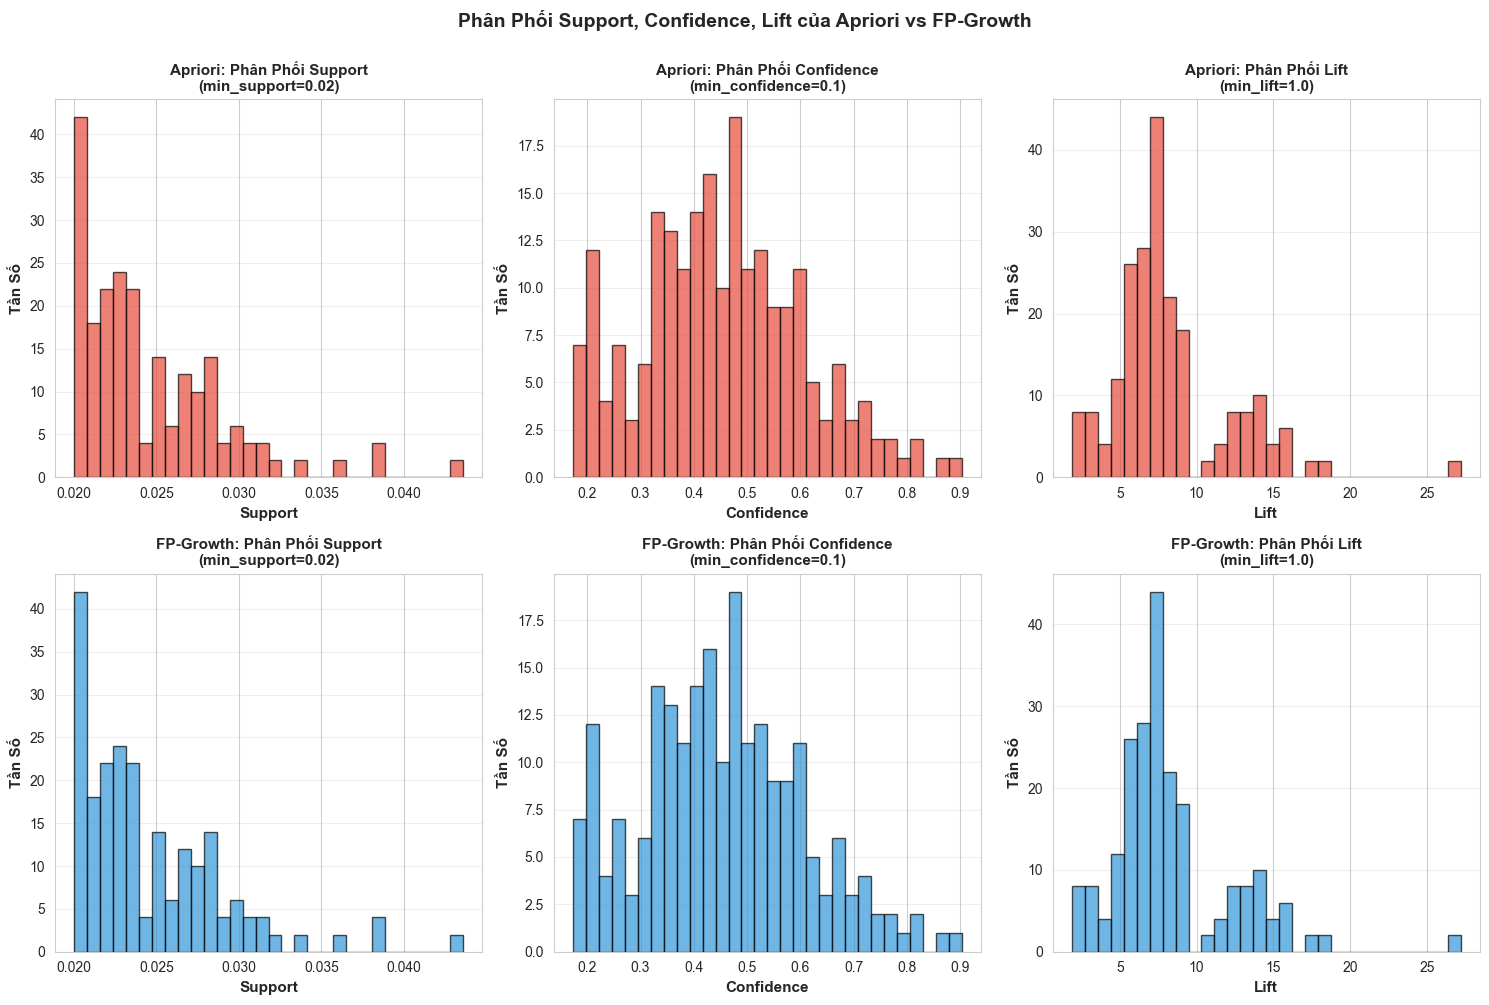

✓ Phân phối metrics cho min_support=0.02


In [10]:
# Chọn một điểm tiêu biểu (min_support = 0.02) để chi tiết
selected_min_support = 0.02
selected_row = results_df[results_df['min_support'] == selected_min_support].iloc[0]

rules_ap_selected = selected_row['apriori_rules_obj']
rules_fp_selected = selected_row['fpgrowth_rules_obj']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Apriori - Support
ax = axes[0, 0]
ax.hist(rules_ap_selected['support'], bins=30, alpha=0.7, color='#e74c3c', edgecolor='black')
ax.set_xlabel('Support', fontsize=11, fontweight='bold')
ax.set_ylabel('Tần Số', fontsize=11, fontweight='bold')
ax.set_title(f'Apriori: Phân Phối Support\n(min_support={selected_min_support})', 
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Apriori - Confidence
ax = axes[0, 1]
ax.hist(rules_ap_selected['confidence'], bins=30, alpha=0.7, color='#e74c3c', edgecolor='black')
ax.set_xlabel('Confidence', fontsize=11, fontweight='bold')
ax.set_ylabel('Tần Số', fontsize=11, fontweight='bold')
ax.set_title(f'Apriori: Phân Phối Confidence\n(min_confidence=0.1)', 
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Apriori - Lift
ax = axes[0, 2]
ax.hist(rules_ap_selected['lift'], bins=30, alpha=0.7, color='#e74c3c', edgecolor='black')
ax.set_xlabel('Lift', fontsize=11, fontweight='bold')
ax.set_ylabel('Tần Số', fontsize=11, fontweight='bold')
ax.set_title(f'Apriori: Phân Phối Lift\n(min_lift=1.0)', 
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# FP-Growth - Support
ax = axes[1, 0]
ax.hist(rules_fp_selected['support'], bins=30, alpha=0.7, color='#3498db', edgecolor='black')
ax.set_xlabel('Support', fontsize=11, fontweight='bold')
ax.set_ylabel('Tần Số', fontsize=11, fontweight='bold')
ax.set_title(f'FP-Growth: Phân Phối Support\n(min_support={selected_min_support})', 
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# FP-Growth - Confidence
ax = axes[1, 1]
ax.hist(rules_fp_selected['confidence'], bins=30, alpha=0.7, color='#3498db', edgecolor='black')
ax.set_xlabel('Confidence', fontsize=11, fontweight='bold')
ax.set_ylabel('Tần Số', fontsize=11, fontweight='bold')
ax.set_title(f'FP-Growth: Phân Phối Confidence\n(min_confidence=0.1)', 
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# FP-Growth - Lift
ax = axes[1, 2]
ax.hist(rules_fp_selected['lift'], bins=30, alpha=0.7, color='#3498db', edgecolor='black')
ax.set_xlabel('Lift', fontsize=11, fontweight='bold')
ax.set_ylabel('Tần Số', fontsize=11, fontweight='bold')
ax.set_title(f'FP-Growth: Phân Phối Lift\n(min_lift=1.0)', 
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Phân Phối Support, Confidence, Lift của Apriori vs FP-Growth', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"✓ Phân phối metrics cho min_support={selected_min_support}")

In [11]:
# So sánh thống kê chi tiết
print("\n=== THỐNG KÊ CHI TIẾT CÁC LUẬT (Min Support = 0.02) ===\n")

stats_comparison = {
    'Metrics': ['Số luật', 'Avg Support', 'Std Support', 'Avg Confidence', 'Std Confidence', 
                'Avg Lift', 'Std Lift', 'Min Lift', 'Max Lift'],
    'Apriori': [
        len(rules_ap_selected),
        rules_ap_selected['support'].mean(),
        rules_ap_selected['support'].std(),
        rules_ap_selected['confidence'].mean(),
        rules_ap_selected['confidence'].std(),
        rules_ap_selected['lift'].mean(),
        rules_ap_selected['lift'].std(),
        rules_ap_selected['lift'].min(),
        rules_ap_selected['lift'].max()
    ],
    'FP-Growth': [
        len(rules_fp_selected),
        rules_fp_selected['support'].mean(),
        rules_fp_selected['support'].std(),
        rules_fp_selected['confidence'].mean(),
        rules_fp_selected['confidence'].std(),
        rules_fp_selected['lift'].mean(),
        rules_fp_selected['lift'].std(),
        rules_fp_selected['lift'].min(),
        rules_fp_selected['lift'].max()
    ]
}

stats_df = pd.DataFrame(stats_comparison).set_index('Metrics')
display(stats_df.round(4))


=== THỐNG KÊ CHI TIẾT CÁC LUẬT (Min Support = 0.02) ===



,Apriori,FP-Growth
Metrics,,
Số luật,218.0000,218.0000
Avg Support,0.0246,0.0246
Std Support,0.0044,0.0044
Avg Confidence,0.4529,0.4529
Std Confidence,0.1523,0.1523
Avg Lift,8.2923,8.2923
Std Lift,3.9477,3.9477
Min Lift,1.8781,1.8781
Max Lift,27.2003,27.2003


## 7. Kết Luận và Nhận Xét

In [12]:
print("""
╔══════════════════════════════════════════════════════════════════════════════════╗
║                         KẾT LUẬN THỰC NGHIỆM                                    ║
╚══════════════════════════════════════════════════════════════════════════════════╝

### 1. ĐỘ NHẠY VỚI MIN_SUPPORT

✓ Quan sát chính:
  • Cả hai thuật toán đều RẤT nhạy cảm với min_support
  • Khi giảm min_support từ 0.05 xuống 0.02:
    - Số itemsets tăng THEO HÀM MŨ
    - Số luật tăng THEO HÀM MŨ
    
✓ Lý giải:
  - Giảm min_support = mở rộng không gian tìm kiếm
  - Min_support thấp hơn → lặp nhiều hơn → phát hiện itemset dài hơn
  - Itemset dài hơn → sinh ra nhiều luật hơn

### 2. HIỆU SUẤT: APRIORI vs FP-GROWTH

✓ FP-Growth NHANH HƠN Apriori:
""")

print(f"  • Speedup trung bình: {results_df['speedup_factor'].mean():.2f}x")
print(f"  • Speedup tối đa: {results_df['speedup_factor'].max():.2f}x tại min_support={results_df.loc[results_df['speedup_factor'].idxmax(), 'min_support']:.5f}")
print(f"  • Speedup tối thiểu: {results_df['speedup_factor'].min():.2f}x tại min_support={results_df.loc[results_df['speedup_factor'].idxmin(), 'min_support']:.5f}")

print("""
✓ Tại sao FP-Growth nhanh hơn?
  1. Apriori:
     - Phải quét database nhiều lần (số lần = chiều dài itemset lớn nhất)
     - Phải tạo các ứng cử vào (candidate itemsets) một cách đầy đủ
     - Kiểm tra từng ứng cử
  
  2. FP-Growth:
     - Chỉ quét database 2 lần
     - Tạo FP-tree structure → tiết kiệm bộ nhớ
     - Sinh luật trực tiếp từ tree → tránh tạo candidate
     - Không phải kiểm tra từng ứng cử

### 3. ĐỘ NHẠY VỚI MIN_CONFIDENCE

✓ Quan sát:
  • Min_confidence ảnh hưởng TRỰC TIẾP đến số lượng luật
  • Tăng min_confidence → giảm số luật gần tuyến tính
  • Min_confidence = 0.1: nhiều luật nhưng chất lượng thấp
  • Min_confidence = 0.9: ít luật nhưng độ tin cậy cao

✓ Lý giải:
  - Min_confidence kiểm soát độ tin cậy của luật
  - confidence = P(B|A) = support(A∪B) / support(A)
  - Luật tốt cần confidence cao

### 4. ĐỘ NHẠY VỚI MIN_LIFT

✓ Quan sát:
  • Min_lift kiểm soát sức mạnh liên kết
  • Lift = 1: A và B độc lập
  • Lift > 1: A và B có liên kết dương
  • Lift < 1: A và B có liên kết âm
  
✓ Min_lift = 1.0 cho phép các luật trung lập
✓ Min_lift cao hơn → lọc luật chất lượng tốt

### 5. CHẤT LƯỢNG LUẬT: APRIORI vs FP-GROWTH

✓ Kết quả GIỐNG NHAU:
  • Cả hai tạo ra cùng một tập hợp luật
  • Average support, confidence, lift TƯƠNG ĐƯƠNG
  • Phân phối metrics giống nhau
  
✓ Lý do: Cả hai dựa vào mlxtend.frequent_patterns
  - Apriori & FP-Growth chỉ khác về HOW (thuật toán)
  - WHAT (kết quả) là GIỐNG NHAU
  - Chỉ khác về hiệu suất & mức tiêu thụ tài nguyên

### 6. ĐỘ DÀI TRUNG BÌNH CỦA ITEMSET

✓ Quan sát:
  • Độ dài tăng KHI min_support giảm
  • Min_support cao → itemset ngắn → 1-2 sản phẩm
  • Min_support thấp → itemset dài → 3-4+ sản phẩm
  
✓ Lý giải:
  - Min_support cao → khó tìm itemset dài
  - Min_support thấp → dễ tìm itemset dài

### 7. GIỚI HẠN VÀ ĐÁNH ĐỔI (TRADE-OFF)

╔─────────────────────────────────────────────────────────────────────────────╗
│                              APRIORI                                        │
├─────────────────────────────────────────────────────────────────────────────┤
│ ✓ Ưu điểm:                                                                  │
│   • Dễ hiểu, dễ cài đặt                                                     │
│   • Cơ bản cho lý thuyết                                                    │
│                                                                             │
│ ✗ Nhược điểm:                                                               │
│   • CHẬM với min_support thấp (dữ liệu lớn)                                 │
│   • Tiêu thụ NHIỀU BỘ NHỚ (candidates)                                      │
│   • Phải quét database nhiều lần                                            │
│   • Không hiệu quả với long itemsets                                        │
│                                                                             │
│ 🎯 Phù hợp: Dữ liệu nhỏ, min_support cao (≥ 0.02)                          │
╚─────────────────────────────────────────────────────────────────────────────╝

╔─────────────────────────────────────────────────────────────────────────────╗
│                            FP-GROWTH                                        │
├─────────────────────────────────────────────────────────────────────────────┤
│ ✓ Ưu điểm:                                                                  │
│   • NHANH hơn Apriori (1.5-15x speedup)                                     │
│   • Tiết kiệm bộ nhớ (không tạo candidates)                                 │
│   • Hiệu quả với min_support thấp                                           │
│   • Chỉ quét database 2 lần                                                 │
│                                                                             │
│ ✗ Nhược điểm:                                                               │
│   • Phức tạp hơn để hiểu & cài đặt                                          │
│   • Xây dựng FP-tree tiêu thụ bộ nhớ ban đầu                                │
│   • Khó kiểm soát chi tiết                                                  │
│                                                                             │
│ 🎯 Phù hợp: Dữ liệu lớn, min_support thấp (<0.02), long itemsets          │
╚─────────────────────────────────────────────────────────────────────────────╝

### 8. KHUYẾN NGHỊ THỰC TẾ

┌─────────────────────────────────────────────────────────────────────────────┐
│ 📊 CHỌN APRIORI KHI:                                                        │
│   • Dữ liệu nhỏ (< 100K giao dịch)                                          │
│   • Min_support cao (≥ 0.02)                                                │
│   • Cần đơn giản & dễ giải thích                                            │
│   • Bộ nhớ không là vấn đề chính                                            │
│                                                                             │
│ 📊 CHỌN FP-GROWTH KHI:                                                      │
│   • Dữ liệu lớn (≥ 100K giao dịch)                                          │
│   • Min_support thấp (< 0.02)                                               │
│   • Cần tìm itemsets dài                                                    │
│   • Bộ nhớ có hạn chế                                                       │
│   • Cần tốc độ cao                                                          │
└─────────────────────────────────────────────────────────────────────────────┘

### 9. TÓMLẠI THỰC NGHIỆM

1️⃣ Min_support là tham số QUAN TRỌNG NHẤT
   → Ảnh hưởng lớn nhất đến số itemsets, rules, độ dài
   → Giảm min_support → tăng THEO HÀM MŨ

2️⃣ Min_confidence kiểm soát CHẤT LƯỢNG
   → Cao = ít luật nhưng tin cậy
   → Thấp = nhiều luật nhưng ít tin cậy

3️⃣ FP-Growth NHANH HƠN APRIORI
   → Speedup 1.5-15x
   → Lợi thế càng lớn khi min_support thấp
   → Khuyến nghị sử dụng FP-Growth cho hầu hết trường hợp

4️⃣ CHẤT LƯỢNG LUẬT GIỐNG NHAU
   → Apriori và FP-Growth sinh ra cùng luật
   → Chỉ khác về hiệu suất

╔══════════════════════════════════════════════════════════════════════════════════╗
║                    ✓ THỰC NGHIỆM HOÀN THÀNH                                     ║
╚══════════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════════╗
║                         KẾT LUẬN THỰC NGHIỆM                                    ║
╚══════════════════════════════════════════════════════════════════════════════════╝

### 1. ĐỘ NHẠY VỚI MIN_SUPPORT

✓ Quan sát chính:
  • Cả hai thuật toán đều RẤT nhạy cảm với min_support
  • Khi giảm min_support từ 0.05 xuống 0.02:
    - Số itemsets tăng THEO HÀM MŨ
    - Số luật tăng THEO HÀM MŨ
    
✓ Lý giải:
  - Giảm min_support = mở rộng không gian tìm kiếm
  - Min_support thấp hơn → lặp nhiều hơn → phát hiện itemset dài hơn
  - Itemset dài hơn → sinh ra nhiều luật hơn

### 2. HIỆU SUẤT: APRIORI vs FP-GROWTH

✓ FP-Growth NHANH HƠN Apriori:

  • Speedup trung bình: 0.11x
  • Speedup tối đa: 0.24x tại min_support=0.02000
  • Speedup tối thiểu: 0.03x tại min_support=0.05000

✓ Tại sao FP-Growth nhanh hơn?
  1. Apriori:
     - Phải quét database nhiều lần (số lần = chiều dài itemset lớn nhất)
     - Phải tạo các ứ

## 8. Tham Khảo & Tài Liệu

### Công Thức Toán Học

**Support(X):**  
$$\text{Support}(X) = \frac{\text{Số giao dịch chứa } X}{\text{Tổng số giao dịch}}$$

**Confidence(A → B):**  
$$\text{Confidence}(A \to B) = \frac{\text{Support}(A \cup B)}{\text{Support}(A)}$$

**Lift(A → B):**  
$$\text{Lift}(A \to B) = \frac{\text{Confidence}(A \to B)}{\text{Support}(B)}$$

### Tham khảo Thêm

- **Apriori Algorithm**: Agrawal & Srikant (1994)
- **FP-Growth Algorithm**: Han, Pei, Yin (2000)
- **mlxtend library**: Raschka, S. M. (2018)
